# Motility Induced Phase Separation in 2D

## Overview

### Questions

* How does **motility-induced phase separation (MIPS)** emerge in systems of purely repulsive active particles?

### Objectives

* Implement a 2D simulation of **Active Brownian Particles (ABPs)** to study MIPS.
* Apply an OverdampedViscous integrator with rotational diffusion to explore activity-driven clustering.


## Boilerplate Code

In [1]:
import itertools

import gsd.hoomd
import hoomd
import numpy

In [2]:
import os

fn = os.path.join(os.getcwd(), "lattice.gsd")
![ -e "$fn" ] && rm "$fn"
fn = os.path.join(os.getcwd(), "MIPS.gsd")
![ -e "$fn" ] && rm "$fn"

The `render` function in the next (hidden) cell will render a snapshot using **fresnel**. Find the source in the [hoomd-examples](https://github.com/glotzerlab/hoomd-examples) repository.

In [3]:
# This is not intended as a full tutorial on fresnel - see the fresnel user
# documentation (https://fresnel.readthedocs.io/) if you would like to learn more.

import warnings

import fresnel
import IPython
import packaging.version

device = fresnel.Device()
tracer = fresnel.tracer.Path(device=device, w=300, h=300)

FRESNEL_MIN_VERSION = packaging.version.parse("0.13.0")
FRESNEL_MAX_VERSION = packaging.version.parse("0.14.0")


def render(snapshot):
    if (
        "version" not in dir(fresnel)
        or packaging.version.parse(fresnel.version.version) < FRESNEL_MIN_VERSION
        or packaging.version.parse(fresnel.version.version) >= FRESNEL_MAX_VERSION
    ):
        warnings.warn(
            f"Unsupported fresnel version {fresnel.version.version} - expect errors."
        )
    central_color = fresnel.color.linear([252 / 255, 41 / 255, 0 / 255])

    L = snapshot.configuration.box[0]
    scene = fresnel.Scene(device)
    geometry = fresnel.geometry.Sphere(
        scene, N=len(snapshot.particles.position), radius=0.5
    )
    geometry.material = fresnel.material.Material(
        color=[0, 0, 0], roughness=0.5, primitive_color_mix=1.0
    )
    geometry.position[:] = snapshot.particles.position[:]
    geometry.color[snapshot.particles.typeid[:] == 0] = central_color
    geometry.radius[snapshot.particles.typeid[:] == 0] = 0.3
    geometry.outline_width = 0.04

    scene.lights = [
        fresnel.light.Light(direction=(0, 0, 1), color=(0.8, 0.8, 0.8), theta=numpy.pi),
        fresnel.light.Light(
            direction=(1, 1, 1), color=(1.1, 1.1, 1.1), theta=numpy.pi / 3
        ),
    ]
    scene.camera = fresnel.camera.Orthographic(
        position=(0, 0, L * 2), look_at=(0, 0, 0), up=(0, 1, 0), height=L * 1.1
    )
    scene.background_alpha = 1
    scene.background_color = (1, 1, 1)
    return IPython.display.Image(tracer.sample(scene, samples=500)._repr_png_())

## Introducing Motility Induced Phase Separation

In this tutorial, we aim to understand an important collective behavior that collections of active particles may present called **motility-induced phase separation (MIPS)**. MIPS is a nonequilibrium phenomenon in which a system of purely repulsive active particles spontaneously exhibits a phase transition to gas-liquid coexistance, separating into coexisting dense and dilute phases. Its mechanism is based on a feedback between density and motility: particles accumulate where their propulsion speed is reduced, and if collisions or crowding cause the swim speed to decrease sufficiently with local density, this accumulation amplifies. The resulting positive feedback destabilizes a homogeneous state and leads to the formation of distinct dense and dilute regions. MIPS is a hallmark collective behavior in active matter systems and has been extensively studied in both theoretical and computational models. 
For a detailed description of MIPS, see Stenhammer's 2021 paper, [An Introduction to Motility-Induced Phase Separation](https://arxiv.org/abs/2112.05024)

MIPS provides a clear visually recognizable example of active behavior, as the emergence of distinct dense and dilute regions is absent in equivalent passive systems. For purely repulsive particles, we can use the activity of the particle and the density of the system to control how we drive our system into a MIPS state.

Below, we replicate much of the set up as in [the previous section](02-Active-Brownian-Particles.ipynb) where we introduced active Brownian particle simulations. 

## Set up the Simulation

We conduct our simulations in two dimensions, making it easier to observe clustering behavior, density fluctuations, and phase separation driven purely by activity and crowding effects. We will first initialize a system of spherical particles with a given particle density in a 2D array. We then save an initial snapshot of the current state of the system.

In [4]:
rho = 0.3  # particle area density
simseed = 1

m = 50
N_particles = m**2
K = numpy.ceil(N_particles ** (1 / 2))
L = (N_particles / rho) ** (1 / 2)
spacing = L / K
x = numpy.linspace(-L / 2, L / 2, int(K), endpoint=False)

position_2D = numpy.array(list(itertools.product(x, repeat=2))) + [
    spacing / 2,
    spacing / 2,
]
position_3D = numpy.hstack([position_2D[:N_particles], numpy.zeros((N_particles, 1))])

frame = gsd.hoomd.Frame()
frame.particles.N = N_particles
frame.particles.position = position_3D[0:N_particles, :]
frame.particles.typeid = [0] * N_particles
frame.configuration.box = [
    L,
    L,
    0,
    0,
    0,
    0,
]
frame.particles.types = ["A"]
frame.particles.mass = [1] * N_particles
frame.particles.orientation = [[1, 0, 0, 0]] * N_particles

with gsd.hoomd.open(name="lattice.gsd", mode="w") as f:
    f.append(frame)

Configure this simulation to run on CPU from this snapshot as we have in previous tutorials. 

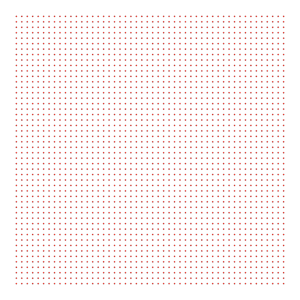

In [5]:
cpu = hoomd.device.CPU()
sim = hoomd.Simulation(device=cpu, seed=simseed)
state = sim.create_state_from_gsd(filename="lattice.gsd")

render(sim.state.get_snapshot())

## Defining Interactions in an Active Particle system

Add a short range WCA pair potential interactions between particles.

In [6]:
wca_sigma = 1
wca_epsilon = 1

cell = hoomd.md.nlist.Cell(buffer=0.4)
wca = hoomd.md.pair.LJ(
    nlist=cell, default_r_cut=(2 ** (1 / 6)) * wca_sigma, default_r_on=0.0, mode="shift"
)
wca.params[("A", "A")] = {"sigma": wca_sigma, "epsilon": wca_epsilon}

integrator = hoomd.md.Integrator(dt=0.001, integrate_rotational_dof=False)
sim.operations.integrator = integrator
integrator.forces.append(wca)

Set up the OverdampedViscous integrator.

Adding temperature to the simulation alters the effective persistence length of the active particles, which directly influence how long it takes for MIPS to be realized due to increasing (or decreasing) random fluctuations. Using the the OverdampedViscous method in HOOMD-blue, we essentially set the effective temperture of the system to zero. Read more about this integrator in the [HOOMD-blue documentation](https://hoomd-blue.readthedocs.io/en/latest/hoomd/md/methods/overdampedviscous.html). Thus, here `kT = 0`.

In [7]:
gamma = 1

filter_all = hoomd.filter.All()
overdamped = hoomd.md.methods.OverdampedViscous(filter=filter_all)
overdamped.gamma.default = gamma
overdamped.gamma_r.default = [gamma, gamma, gamma]

integrator.methods.append(overdamped)

The spontaneous development of MIPs in a system is highly dependent on Pe and particle density. Based on previous studies of active spherical particle systems, a general rule of thumb is: 
- Pe < 10: mostly homogeneous, little clustering at some higher densities
- Pe ≈ 20–80: MIPS starts to emerge (depending on density)
- Pe > 100: strong phase separation likely

More information on Pe numbers for different systems can be found in [Cates & Tailleur (2015)](https://doi.org/10.1146/annurev-conmatphys-031214-014710) and [Marchetti et al. (2023)](https://pubs.rsc.org/en/content/articlelanding/2023/sm/d3sm01059g). 

For this tutorial, we want to place our system in the regime where we can expect MIPS above certain intermediate densities. Since, we have previously set `gamma=1` and `sigma=1`, we do this by setting our `active_force = 2` ($F_{\text{active}}$)  and `rotational_diffusion = 0.1` ($D_{r}$). Thus, our Péclet number is 20 according to the relation we gave in [section 02 of this tutorial sequence](02-Active-Brownian-Particles.ipynb): $$ Pe = \frac{F_{active} * \text{$\sigma$}}{D_{r} * \text{$\gamma$}}$$

In [8]:
activity = 2

active = hoomd.md.force.Active(filter=filter_all)
active.active_force["A"] = (activity, 0, 0)
active.active_torque["A"] = (0, 0, 0)

integrator.forces.append(active)

rotational_diffusion_updater = active.create_diffusion_updater(
    trigger=1, rotational_diffusion=0.1
)
sim.operations += rotational_diffusion_updater

Briefly run the simulation and get an initial snapshot at this density.

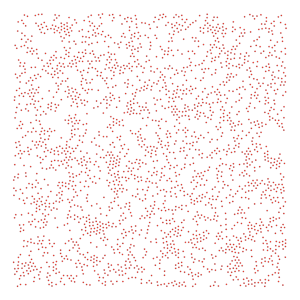

In [9]:
logger = hoomd.logging.Logger(["particle", "constraint"])
gsd_oper = hoomd.write.GSD(
    trigger=hoomd.trigger.Periodic(100),
    filename="MIPS.gsd",
    logger=logger,
    mode="wb",
    dynamic=["momentum", "property"],
    filter=filter_all,
)

sim.operations += gsd_oper

sim.run(10000)
gsd_oper.flush()
render(sim.state.get_snapshot())

## Density and 2D MIPS

Now that we have set up a 2D simulation of hard spheres of a reasonably high Péclet number, it is easy to induce MIPS by increasing the system's density which affects collision frequency and cluster formation. Increasing density generally promotes phase separation by enhancing particle interactions. MIPS usually emerges above a critical packing fraction around 0.3–0.4 for sufficiently Pe. By systematically varying both density and activity, one could map out the phase diagram and identify regimes where the system spontaneously separates into dense clusters and dilute gas-like regions. 

For the sake of this tutorial, we will compress our 2D system with Pe=20 to visualize MIPS by following a very similar compression method as in [earlier HOOMD-blue tutorials]((../01-Introducing-Molecular-Dynamics/00-index.ipynb)).


In [10]:
initial_box = sim.state.box
initial_rho = sim.state.N_particles / (initial_box.Lx * initial_box.Ly)

final_rho = 0.55
final_area = sim.state.N_particles / final_rho
final_L = final_area ** (1 / 2)

final_box = hoomd.Box.from_box(initial_box)  # make a copy of initial_box
final_box.Lx = final_L
final_box.Ly = final_L
final_box.Lz = 0

ramp = hoomd.variant.Ramp(A=0, B=1, t_start=sim.timestep, t_ramp=20000)

interpolated_box = hoomd.variant.box.Interpolate(
    initial_box=initial_box, final_box=final_box, variant=ramp
)

box_resize = hoomd.update.BoxResize(
    trigger=hoomd.trigger.Periodic(10), box=interpolated_box, filter=filter_all
)

sim.operations.updaters.append(box_resize)

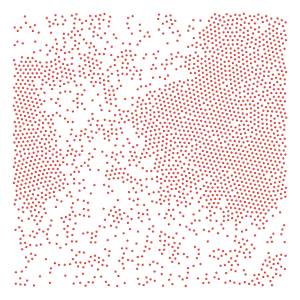

In [11]:
sim.run(200000)
gsd_oper.flush()

render(sim.state.get_snapshot())

By visual inspection, we can see gas-liquid coexistance that we expect from a characteristic MIPS. There are numerous other more quantitive ways to document this behavior that we could do using analysis tools like [freud](https://freud.readthedocs.io/en/latest/) for instance.